# Supplementary Figure 5e — drug-pair similarity, 2D vs 3D, by MoA class

Each point is one drug pair: x = cosine similarity in 2D, y = in 3D (scAgg). Above the
diagonal = more similar in 3D.


In [1]:
# --- repo path bootstrap ---
import sys, pathlib
ROOT = next(p for p in pathlib.Path.cwd().parents if (p / "utils" / "paths.py").is_file())
sys.path.insert(0, str(ROOT))
from utils.paths import derived, metadata, profiles, require
from utils.panels import save_panel

from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42


In [2]:
# Pair similarities. Each compound is represented by one concentration -- the one
# with the highest mean grit -- profiled from selected_data.

CONTROLS = {"dmso", "etop", "fenb", "sorb", "stau", "water"}

grit_2d = pd.read_parquet(require(profiles("exp1_main", "grit_data_2D_HCT116.parquet")))
grit_3d = pd.read_parquet(require(profiles("exp1_main", "grit_data_aggregates_HCT116.parquet")))
sel_2d = pd.read_parquet(require(profiles("exp1_main", "selected_data_2D_HCT116.parquet")))
sel_3d = pd.read_parquet(require(profiles("exp1_main", "selected_data_aggregates_HCT116.parquet")))

feats_2d = [c for c in sel_2d.columns if not c.startswith("Metadata_")]
feats_3d = [c for c in sel_3d.columns if not c.startswith("Metadata_")]


def cosine_sim(a, b):
    norm = np.linalg.norm(a) * np.linalg.norm(b)
    return float(np.dot(a, b) / norm) if norm > 0 else float("nan")


def best_profile(sel_df, feats, grit_df, cmpd):
    """Mean profile of the single concentration with the highest mean grit."""
    g = (grit_df[grit_df["Metadata_cmpdname"] == cmpd]
         .groupby("Metadata_cmpd_conc")["Metadata_grit"].mean().dropna())
    if g.empty:
        return pd.Series(np.nan, index=feats, dtype=float)
    sub = sel_df[(sel_df["Metadata_cmpdname"] == cmpd)
                 & (sel_df["Metadata_cmpd_conc"] == g.idxmax())]
    return sub[feats].mean()


treated = lambda d: {c for c in d["Metadata_cmpdname"].unique() if c not in CONTROLS}
drugs = sorted(treated(sel_2d) & treated(sel_3d))
prof = {d: {"2d": best_profile(sel_2d, feats_2d, grit_2d, d),
            "3d": best_profile(sel_3d, feats_3d, grit_3d, d)} for d in drugs}

rows = []
for a, b in combinations(drugs, 2):
    p2a, p2b = prof[a]["2d"], prof[b]["2d"]
    p3a, p3b = prof[a]["3d"], prof[b]["3d"]
    # Each modality keeps its own feature set; a pair is compared on the features
    # finite for both of its members.
    c2 = p2a.dropna().index.intersection(p2b.dropna().index)
    c3 = p3a.dropna().index.intersection(p3b.dropna().index)
    rows.append({"drug_a": a, "drug_b": b,
                 "s2": cosine_sim(p2a[c2].values, p2b[c2].values),
                 "s3": cosine_sim(p3a[c3].values, p3b[c3].values)})

pair_sim = pd.DataFrame(rows).dropna(subset=["s2", "s3"])
dropped = sorted(set(drugs) - (set(pair_sim.drug_a) | set(pair_sim.drug_b)))
if dropped:
    print(f"no finite grit, pairs dropped: {dropped}")
sim2 = dict(zip(zip(pair_sim.drug_a, pair_sim.drug_b), pair_sim.s2))
sim3 = dict(zip(zip(pair_sim.drug_a, pair_sim.drug_b), pair_sim.s3))
shared = list(sim2)
print(f"{len(shared)} pairs over "
      f"{len(set(pair_sim.drug_a) | set(pair_sim.drug_b))} drugs")


no finite grit, pairs dropped: ['Bortezomib (PS-341)']
1275 pairs over 51 drugs


In [3]:
# The classes below are derived from Metadata_target and Metadata_pathway in the parquet file. 
meta = pd.read_csv(require(metadata("spher_colo52-metadata.csv", "exp1_main")))
ann = (meta[['cmpdname', 'target', 'target_class', 'pathway']]
       .drop_duplicates('cmpdname').set_index('cmpdname'))
TARGET = ann['target'].fillna('').to_dict()
CLASS = ann['target_class'].fillna('').to_dict()
PATHWAY = ann['pathway'].fillna('').to_dict()


def bucket(name):
    """Coarse mechanism for one compound: curated class first, annotated target next.

    target_class refines `target` where that field is mechanistically ambiguous: it
    puts five DNA-damage agents under 'DNA/RNA Synthesis', of which three are
    antimetabolites and two -- oxaliplatin and temozolomide -- are not.
    """
    curated = str(CLASS.get(name, '')).strip()
    if curated:
        return {'Topoisomerase I': 'MDM2i/TopoI'}.get(curated, curated)
    target = str(TARGET.get(name, ''))
    if 'PARP' in target:              return 'PARPi'
    if 'Mdm2' in target:              return 'MDM2i/TopoI'
    if 'Topoisomerase' in target:     return 'MDM2i/TopoI'
    if PATHWAY.get(name) == 'MAPK':   return 'MAPK'
    return 'Other'


def pair_class(a, b):
    """Class of an unordered pair, from the set of its two buckets."""
    b2 = {bucket(a), bucket(b)}
    if b2 == {'MAPK'}:                                  return 'MAPK \u00d7 MAPK'
    if b2 == {'Antimetabolite'}:                  return 'Antimetabolite \u00d7 Antimetabolite'
    if b2 == {'Antimetabolite', 'PARPi'}:         return 'Antimetabolite \u00d7 PARPi'
    if b2 == {'Antimetabolite', 'MDM2i/TopoI'}: return 'Antimetabolite \u00d7 MDM2i / Topo I'
    return 'Other'


pairs = pd.DataFrame(
    [{'drug_a': a, 'drug_b': b, 's2': sim2[(a, b)], 's3': sim3[(a, b)],
      'pair_class': pair_class(a, b)} for a, b in shared]
)
print(f"{len(pairs)} pairs over "
      f"{len(set(pairs.drug_a) | set(pairs.drug_b))} drugs")
print()
print('DNA Damage compounds and the bucket each falls in:')
for name in sorted(n for n in TARGET if PATHWAY.get(n) == 'DNA Damage'):
    print(f'  {bucket(name):<16} {CLASS.get(name, "") or "(from target)":<16} {name}')
print()
print(pairs.pair_class.value_counts().to_string())

# Full pair table, beyond what the panel plots.
out = derived("exp1_main", "drug_pair_similarity_2D_vs_3D_HCT116.csv")
pairs.to_csv(out, index=False)
print(f"wrote {len(pairs)} pairs -> {out.relative_to(ROOT)}")


1275 pairs over 51 drugs

DNA Damage compounds and the bucket each falls in:
  Antimetabolite   Antimetabolite   Fluorouracil (5-Fluoracil, 5-FU)
  Antimetabolite   Antimetabolite   Gemcitabine
  PARPi            PARPi            Olaparib (AZD2281, Ku-0059436)
  Platinum         Platinum         Oxaliplatin
  MDM2i/TopoI      Topoisomerase I  SN-38
  Alkylator        Alkylator        Temozolomide
  Antimetabolite   Antimetabolite   Trifluridine
  PARPi            PARPi            Veliparib (ABT-888)

pair_class
Other                              1212
MAPK × MAPK                          45
Antimetabolite × MDM2i / Topo I       9
Antimetabolite × PARPi                6
Antimetabolite × Antimetabolite       3


In [4]:
# Palette and draw order as published: "Other" underneath in light grey, the four
# labelled classes on top.
PAIR_COLOURS = {
    "MAPK \u00d7 MAPK":                        "#a8a8a8",
    "Antimetabolite \u00d7 Antimetabolite":      "#1f77b4",
    "Antimetabolite \u00d7 PARPi":              "#ff7f0e",
    "Antimetabolite \u00d7 MDM2i / Topo I":      "#d62728",
    "Other":                                     "#e6e6e6",   # background cloud
}
ORDER = ["Other", "MAPK \u00d7 MAPK", "Antimetabolite \u00d7 Antimetabolite",
         "Antimetabolite \u00d7 PARPi", "Antimetabolite \u00d7 MDM2i / Topo I"]

# Labelled pairs, keyed on the full name in Metadata_cmpdname.
FLUOR = "Fluorouracil (5-Fluoracil, 5-FU)"
AMG = "AMG232 (Navtemadlin)"
OLAPA = "Olaparib (AZD2281, Ku-0059436)"
VELIP = "Veliparib (ABT-888)"
HIGHLIGHT = [("Nutlin-3", "Trifluridine"), ("Gemcitabine", "SN-38"),
             (AMG, FLUOR), ("SN-38", "Trifluridine"), (FLUOR, "SN-38"),
             (OLAPA, "Trifluridine"), (FLUOR, OLAPA),
             (VELIP, "Trifluridine"), (VELIP, "Gemcitabine"),
             (OLAPA, "Gemcitabine"), (FLUOR, VELIP)]
SHORT = {FLUOR: "Fluor", "Trifluridine": "Trifl", "Gemcitabine": "Gemci",
         "Nutlin-3": "Nutli", AMG: "AMG23", OLAPA: "Olapa", "SN-38": "SN-38",
         VELIP: "Velip"}


261 of 1275 pairs fall outside the plotted range
[save_panel] SupplFig5e -> SupplFig5e.csv (1275 rows), SupplFig5e.pdf


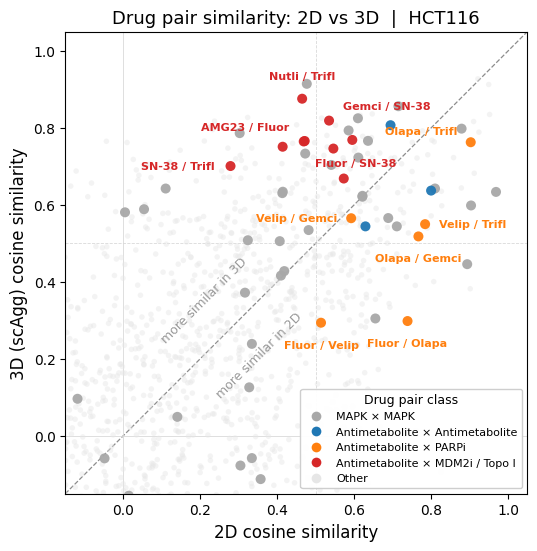

In [5]:
fig, ax = plt.subplots(figsize=(6, 6))

# Axes crop to -0.15..1.05; pairs below that are outside the view and reported.
lo, hi = -0.15, 1.05
_out = pairs[(pairs.s2 < lo) | (pairs.s3 < lo)]
print(f'{len(_out)} of {len(pairs)} pairs fall outside the plotted range')

ax.axhline(0, color="0.85", lw=0.6); ax.axvline(0, color="0.85", lw=0.6)
ax.axhline(0.5, color="0.85", lw=0.6, ls="--"); ax.axvline(0.5, color="0.85", lw=0.6, ls="--")
ax.plot([lo, hi], [lo, hi], ls="--", lw=0.9, color="0.55", zorder=1)
# Guides parallel to the diagonal, one either side.
_ann = dict(transform=ax.transAxes, rotation=45, rotation_mode="anchor",
            color="0.6", fontsize=9, ha="center", va="center")
ax.text(0.30, 0.42, "more similar in 3D", **_ann)
ax.text(0.42, 0.30, "more similar in 2D", **_ann)

for cls in ORDER:
    sub = pairs[pairs.pair_class == cls]
    other = cls == "Other"
    # no edge on any class, and the background cloud stays faint
    ax.scatter(sub.s2, sub.s3, s=16 if other else 52, c=PAIR_COLOURS[cls],
               edgecolor="none", linewidth=0,
               alpha=0.45 if other else 0.95, zorder=2 if other else 3, label=cls)

# Label offsets: dx/dy in data units, (ha, va) anchor the text to its point.
LABEL_POS = {
    frozenset({"Nutli", "Trifl"}): (0.00,   0.045, "center", "bottom"),
    frozenset({"Gemci", "SN-38"}): (0.035,  0.025, "left",   "bottom"),
    frozenset({"AMG23", "Fluor"}): (-0.04,  0.022, "right",  "bottom"),  # shares a point with Fluor/SN-38
    frozenset({"Fluor", "SN-38"}): (0.030, -0.045, "left",   "top"),     # so this one is pushed down-right
    frozenset({"SN-38", "Trifl"}): (-0.04,  0.00,  "right",  "center"),
    frozenset({"Olapa", "Trifl"}): (-0.035, 0.015, "right",  "bottom"),
    frozenset({"Fluor", "Olapa"}): (0.00,  -0.045, "center", "top"),
    frozenset({"Velip", "Trifl"}): (0.035,  0.00,  "left",   "center"),
    frozenset({"Velip", "Gemci"}): (-0.035, 0.00,  "right",  "center"),
    frozenset({"Olapa", "Gemci"}): (0.00,  -0.045, "center", "top"),
    frozenset({"Fluor", "Velip"}): (0.00,  -0.045, "center", "top"),
}

for a, b in HIGHLIGHT:
    row = pairs[((pairs.drug_a == a) & (pairs.drug_b == b))
                | ((pairs.drug_a == b) & (pairs.drug_b == a))]
    if not len(row):
        print(f'WARNING: highlight pair not found: {a} / {b}')
        continue
    r = row.iloc[0]
    sa, sb = SHORT.get(a, a), SHORT.get(b, b)
    dx, dy, ha, va = LABEL_POS.get(frozenset({sa, sb}), (0.0, 0.045, "center", "bottom"))
    ax.text(r.s2 + dx, r.s3 + dy, f"{sa} / {sb}", fontsize=8, fontweight="bold",
            color=PAIR_COLOURS[r.pair_class], ha=ha, va=va, zorder=6)

ax.set_xlabel("2D cosine similarity", fontsize=12)
ax.set_ylabel("3D (scAgg) cosine similarity", fontsize=12)
ax.set_title("Drug pair similarity: 2D vs 3D  |  HCT116", fontsize=13)
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect("equal")
ax.legend(handles=[Line2D([0], [0], marker="o", ls="", markerfacecolor=PAIR_COLOURS[c],
                          markeredgecolor="none",
                          markersize=7, label=c) for c in ORDER[1:] + ["Other"]],
          title="Drug pair class", loc="lower right", fontsize=8, title_fontsize=9,
          frameon=True, framealpha=0.95)

save_panel(fig, "SupplFig5e", data=pairs,
           caption="Drug-pair similarity 2D vs 3D, coloured by MoA pair class, HCT116",
           notebook="analysis/3_SupplFigure5/3_SupplFig5e_moa_class.ipynb")
plt.show()
